In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
import seaborn as sns

In [2]:
from skimpy import clean_columns

In [3]:
df = pd.read_csv('../data/ecommerce_product_dataset.csv')
df.head()

,ProductID,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded,City
0,1,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-10,Albuquerque
1,2,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-28,Queens
2,3,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-20,Austin
3,4,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-05,Dallas
4,5,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-10,Tucson


In [4]:
df.describe()

,ProductID,Price,Rating,NumReviews,StockQuantity,Discount,Sales
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,253.77551,3.025600,2498.753000,495.395000,0.251640,1011.037000
std,288.819436,141.40362,1.151004,1463.241871,292.799253,0.146455,582.113466
min,1.000000,10.11000,1.000000,3.000000,0.000000,0.000000,0.000000
25%,250.750000,133.09250,2.100000,1201.750000,241.750000,0.130000,502.000000
50%,500.500000,251.31000,3.100000,2476.000000,505.000000,0.250000,998.000000
75%,750.250000,375.82750,4.000000,3797.500000,743.500000,0.380000,1540.000000
max,1000.000000,499.74000,5.000000,4994.000000,993.000000,0.500000,1997.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductID      1000 non-null   int64  
 1   ProductName    1000 non-null   str    
 2   Category       1000 non-null   str    
 3   Price          1000 non-null   float64
 4   Rating         1000 non-null   float64
 5   NumReviews     1000 non-null   int64  
 6   StockQuantity  1000 non-null   int64  
 7   Discount       1000 non-null   float64
 8   Sales          1000 non-null   int64  
 9   DateAdded      1000 non-null   str    
 10  City           1000 non-null   str    
dtypes: float64(3), int64(4), str(4)
memory usage: 125.9 KB


In [6]:
# Global constants for Bayesian Average
C = df["Rating"].mean()
m = df["NumReviews"].quantile(0.25)

m

np.float64(1201.75)

In [7]:
# 1. Bayesian Weighted Rating, prevent flukes in the average rating based on 
def bayesian_rating(row):
    v = row["NumReviews"]
    R = row["Rating"]
    return round(((v * R) / (v + m)) + ((m * C) / (v + m) ), 1)

df['WeightedRating'] = df.apply(bayesian_rating, axis=1)


In [8]:
df.head()

,ProductID,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded,City,WeightedRating
0,1,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-10,Albuquerque,2.0
1,2,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-28,Queens,2.5
2,3,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-20,Austin,2.4
3,4,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-05,Dallas,3.3
4,5,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-10,Tucson,2.4


In [9]:
c = df.groupby('Category')['Rating']
df['CategoryRating'] = round(c.transform('mean'), 1)


In [10]:
type(date.today())

datetime.date

In [11]:
df['DateAdded'] = pd.to_datetime(df['DateAdded']).dt.date
days = date.today() - df['DateAdded']

days_elapsed = days.apply(lambda x:x.days)
days_elapsed

df['SalesRate'] = round((df['Sales'] / days_elapsed), 2)

df['SupplyDays'] = round((df['StockQuantity'] / df['SalesRate']), 2)

df

,ProductID,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded,City,WeightedRating,CategoryRating,SalesRate,SupplyDays
0,1,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-10,Albuquerque,2.0,2.8,0.49,40.82
1,2,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-28,Queens,2.5,2.8,1.33,498.50
2,3,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-20,Austin,2.4,2.8,0.26,1765.38
3,4,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-05,Dallas,3.3,2.8,1.94,244.85
4,5,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-10,Tucson,2.4,2.8,1.44,577.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Throw Blanket,Blankets,207.72,2.3,1973,16,0.46,325,2024-02-13,Baton Rouge,2.6,3.2,0.38,42.11
996,997,Fleece Blanket,Blankets,268.60,3.2,841,201,0.39,1546,2023-07-01,Worcester,3.1,3.2,1.42,141.55
997,998,Throw Blanket,Blankets,92.74,2.8,3454,880,0.02,1295,2023-10-29,Raleigh,2.9,3.2,1.34,656.72
998,999,Weighted Blanket,Blankets,152.28,1.3,2850,752,0.34,1962,2023-10-28,Nashville,1.8,3.2,2.02,372.28


### Sales distribution per category

C:\Users\Elot\AppData\Local\Temp\ipykernel_10536\3394661825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


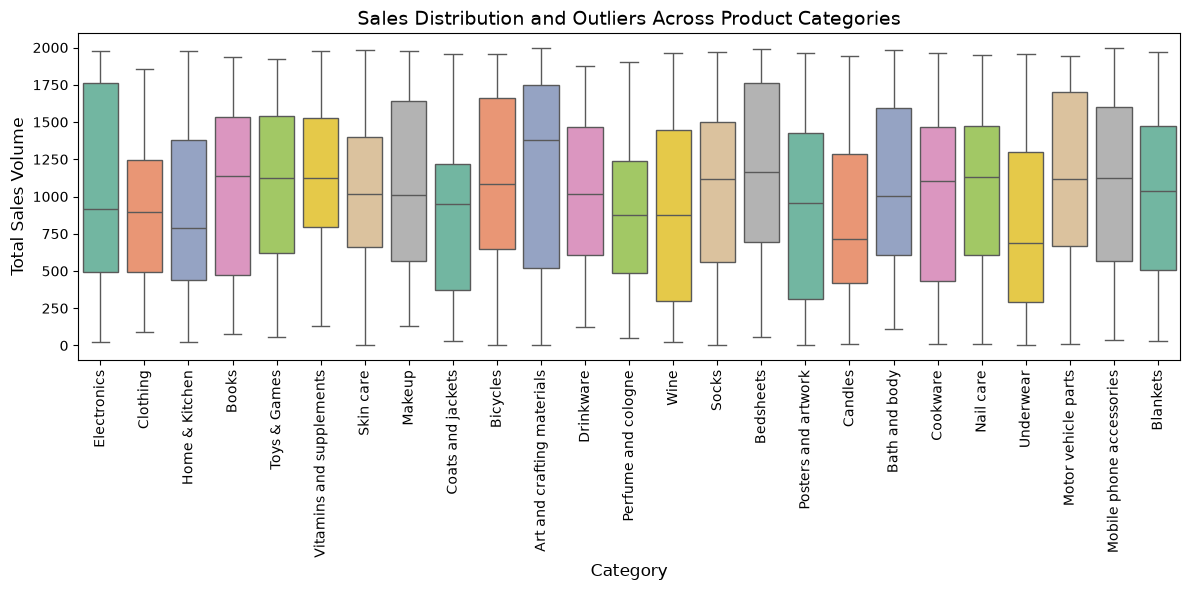

In [12]:
plt.figure(figsize=(12, 6))

# Boxplot comparing sales distribution per category
sns.boxplot(
    x="Category",
    y="Sales",
    data=df,
    palette="Set2"
)

plt.title("Sales Distribution and Outliers Across Product Categories", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales Volume", fontsize=12)
plt.xticks(rotation=90) # Rotate category text slightly if they overlap
plt.tight_layout()
plt.show()

### Top 10 Products

C:\Users\Elot\AppData\Local\Temp\ipykernel_10536\718351230.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


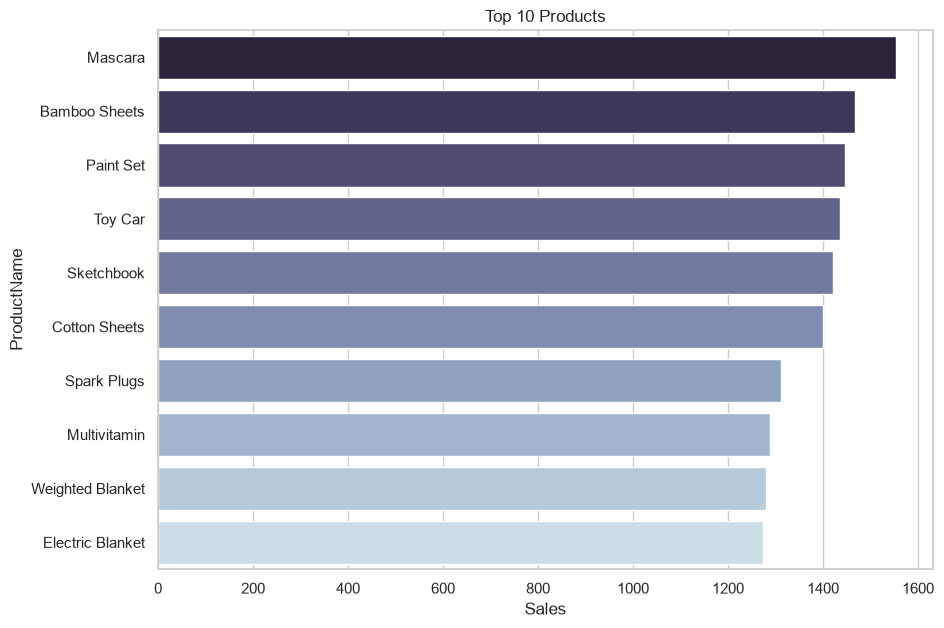

In [47]:
plt.figure(figsize=(10, 7))

# Convert the series into data frame for seaborn plotting use

top_products = (df.groupby("ProductName")['Sales'].mean().sort_values(ascending=False).head(10).to_frame()).reset_index()

palette = sns.color_palette("ch:s=.25,rot=-.25", n_colors=10)[::-1]

ax = sns.barplot(
    data=top_products,
    x="Sales",
    y="ProductName",
    palette=palette
)

plt.title(label="Top 10 Products")
plt.show()

### Top 10 Categories

C:\Users\Elot\AppData\Local\Temp\ipykernel_10536\2959804652.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


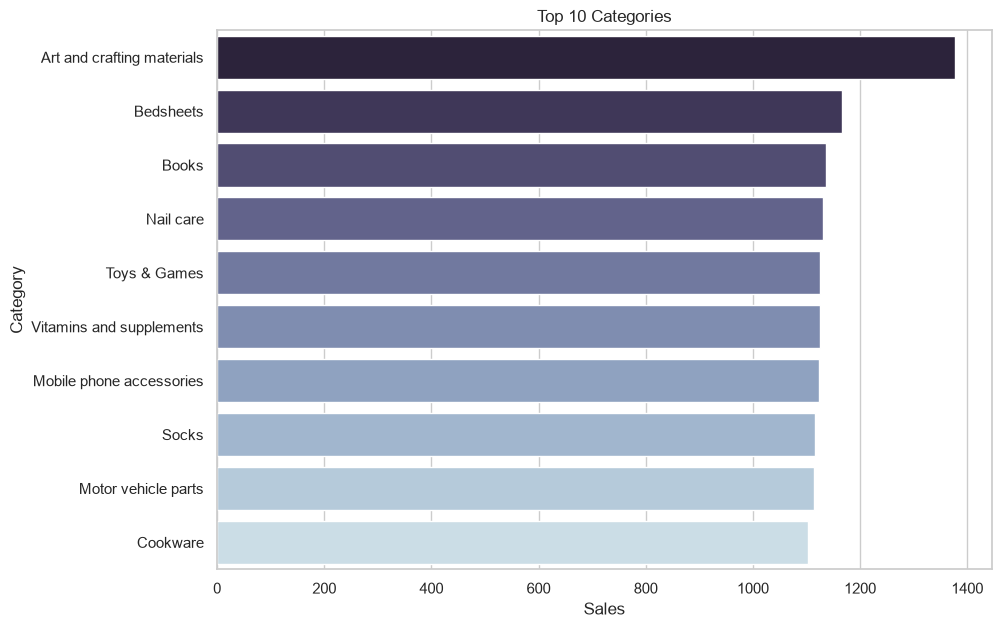

In [52]:
plt.figure(figsize=(10, 7))

# Convert the series into data frame for seaborn plotting use

top_products = (df.groupby("Category")['Sales'].median().sort_values(ascending=False).head(10).to_frame()).reset_index()

palette = sns.color_palette("ch:s=.25,rot=-.25", n_colors=10)[::-1]

ax = sns.barplot(
    data=top_products,
    x="Sales",
    y="Category",
    palette=palette
)

plt.title(label="Top 10 Categories")
plt.show()

### Top 10 Critical Stockout Risks


C:\Users\Elot\AppData\Local\Temp\ipykernel_10536\2364262320.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


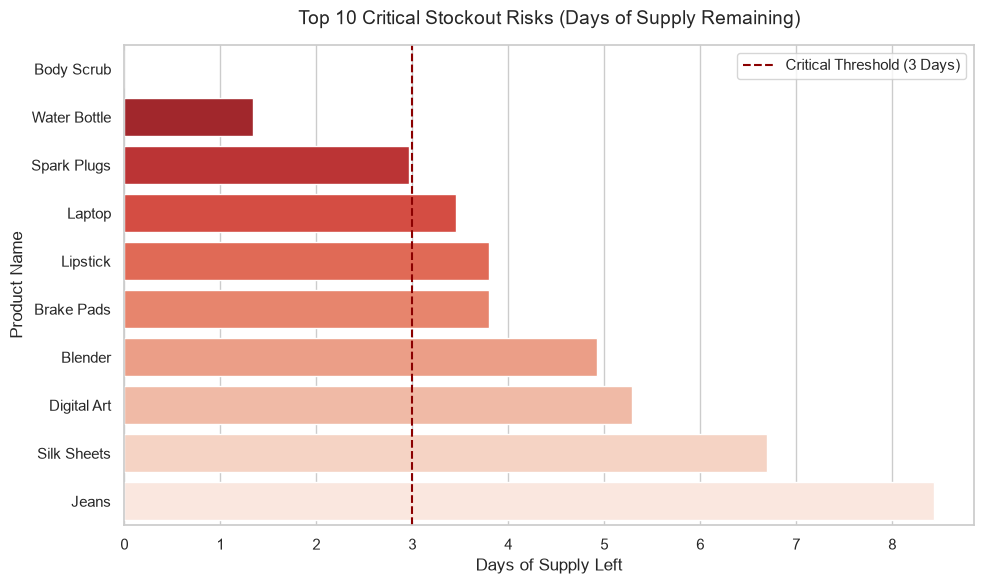

In [13]:

# Filter for your critical items and sort
critical_stock = df.sort_values(by="SupplyDays").head(10)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create horizontal bar plot
ax = sns.barplot(
    x="SupplyDays",
    y="ProductName",
    data=critical_stock,
    palette="Reds_r" # Crimson gradient highlighting the worst offenders
)

plt.title("Top 10 Critical Stockout Risks (Days of Supply Remaining)", fontsize=14, pad=15)
plt.xlabel("Days of Supply Left", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.axvline(x=3, color="darkred", linestyle="--", label="Critical Threshold (3 Days)")
plt.legend()
plt.tight_layout()
plt.show()

### Bubble Chart for Raw Rating and Weighted Rating (Bayesian Average)

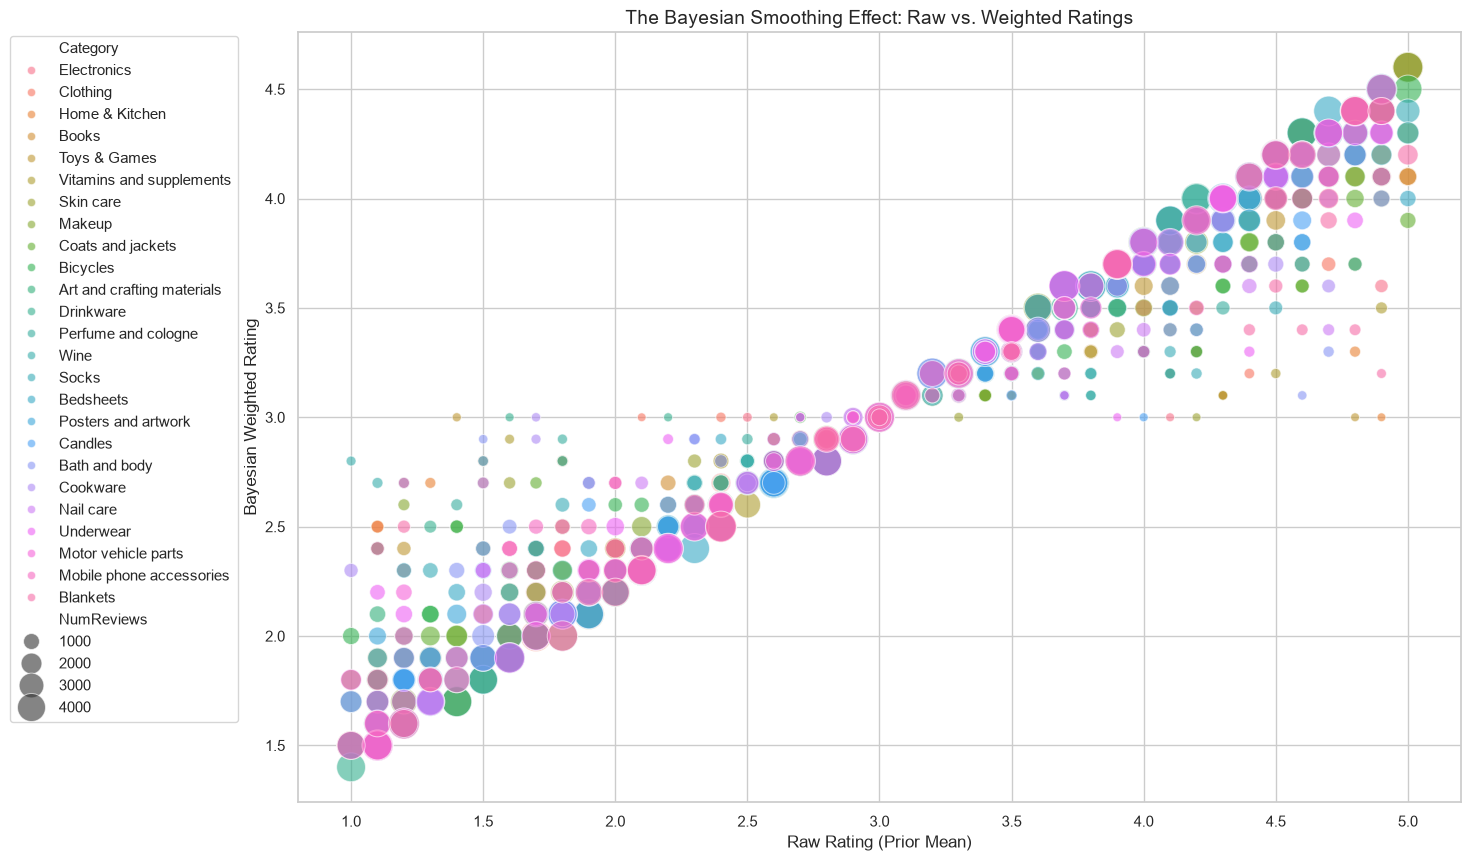

In [14]:
# Bubble Chart for weighted rating and actual rating

plt.figure(figsize=(15, 10))

sns.set_theme(style="whitegrid")

ax = sns.scatterplot(
    data=df,
    x="Rating",
    y="WeightedRating",
    hue="Category",
    size="NumReviews",
    sizes=(40,500),
    alpha=0.6
)

plt.title("The Bayesian Smoothing Effect: Raw vs. Weighted Ratings", fontsize=14)
plt.xlabel("Raw Rating (Prior Mean)", fontsize=12)
plt.ylabel("Bayesian Weighted Rating", fontsize=12)
plt.legend(loc="center", bbox_to_anchor=(-0.4, 0.3, 0.5, 0.5))

plt.show()

### Performance per Category Quadrant Chart

C:\Users\Elot\AppData\Local\Temp\ipykernel_10536\513332775.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center", bbox_to_anchor=(-0.4, 0.3, 0.5, 0.5))


626.75
1413.25
1020.0


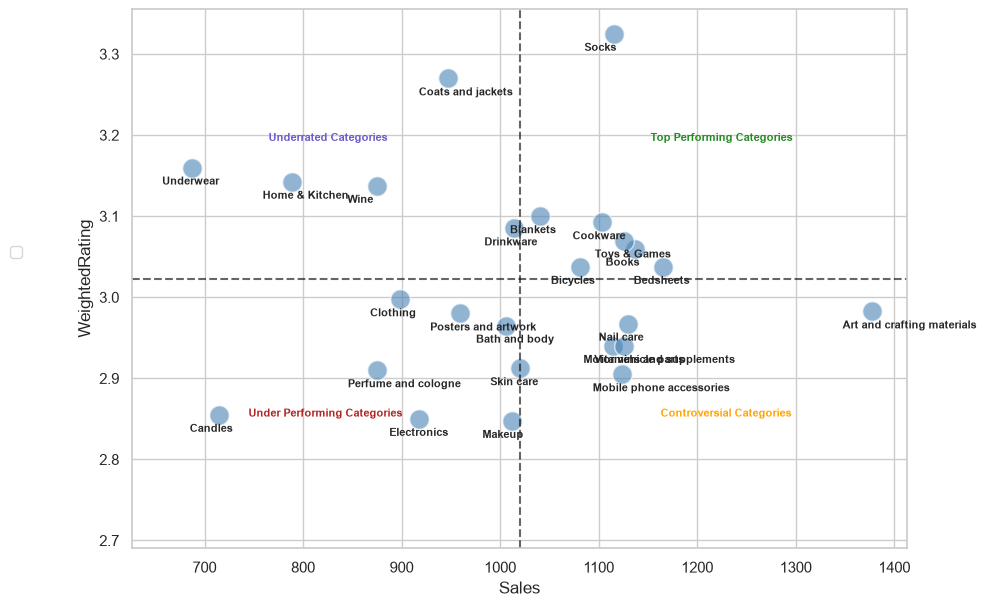

In [15]:
plt.figure(figsize=(10, 7))


category_summary = df.groupby("Category").agg({
    'Sales': 'median',
    'WeightedRating': 'mean'
}).reset_index()


# Plot only the category averages
sns.scatterplot(
    x="Sales", 
    y="WeightedRating", 
    data=category_summary,
    s=200,                  # Make the dots nice and large
    color="steelblue",
    alpha=0.6
)

sns.color_palette("husl", 9)

# Add text labels right next to each dot so you can read category names instantly
for i in range(category_summary.shape[0]):
    plt.text(
        x=category_summary.Sales[i] -30, # slight offset to the right
        y=category_summary.WeightedRating[i] - 0.021,
        s=category_summary.Category[i],
        fontdict=dict(size=8, weight='bold')
    )

# Dynamic Crosshairs (using the middle of your summary data)
sales_crosshair = category_summary["Sales"].median()
rating_crosshair = category_summary["WeightedRating"].mean()

plt.axvline(x=sales_crosshair, color="black", linestyle="--", alpha=0.6)
plt.axhline(y=rating_crosshair, color="black", linestyle="--", alpha=0.6)
plt.legend(loc="center", bbox_to_anchor=(-0.4, 0.3, 0.5, 0.5))

# Find the maximum distance from the crosshair to any data point
max_sales_dist = max(
    abs(sales_crosshair - category_summary["Sales"].min()), 
    abs(category_summary["Sales"].max() - sales_crosshair)
)

max_rating_dist = max(
    abs(rating_crosshair - category_summary["WeightedRating"].min()), 
    abs(category_summary["WeightedRating"].max() - rating_crosshair)
)

# Add a tiny bit of padding (e.g., 10%) so edge points don't get clipped
sales_padding = max_sales_dist * 1.1
rating_padding = max_rating_dist * 1.1

# Force the axis limits to be perfectly symmetrical around the centers
plt.xlim(sales_crosshair - sales_padding, sales_crosshair + sales_padding)
plt.ylim(rating_crosshair - rating_padding, rating_crosshair + rating_padding)

print((sales_crosshair - sales_padding))
print((sales_crosshair + sales_padding))

print(sales_crosshair)
plt.text(sales_crosshair * 1.13, rating_crosshair + 0.17, "Top Performing Categories", fontdict=dict(size=8, weight="bold"), color="forestgreen")
plt.text(sales_crosshair * 1.14, rating_crosshair - 0.17, "Controversial Categories", fontdict=dict(size=8, weight="bold"), color="orange")
plt.text(sales_crosshair * 0.75, rating_crosshair + 0.17, "Underrated Categories", fontdict=dict(size=8, weight="bold"), color="slateblue")
plt.text(sales_crosshair * 0.73, rating_crosshair - 0.17, "Under Performing Categories", fontdict=dict(size=8, weight="bold"), color="firebrick")

plt.show()


In [55]:
df[["Sales", "Rating"]]

,Sales,Rating
0,466,1.7
1,1332,2.3
2,252,1.8
3,1806,3.4
4,1508,1.8
...,...,...
995,325,2.3
996,1546,3.2
997,1295,2.8
998,1962,1.3


## Correlation Matrix

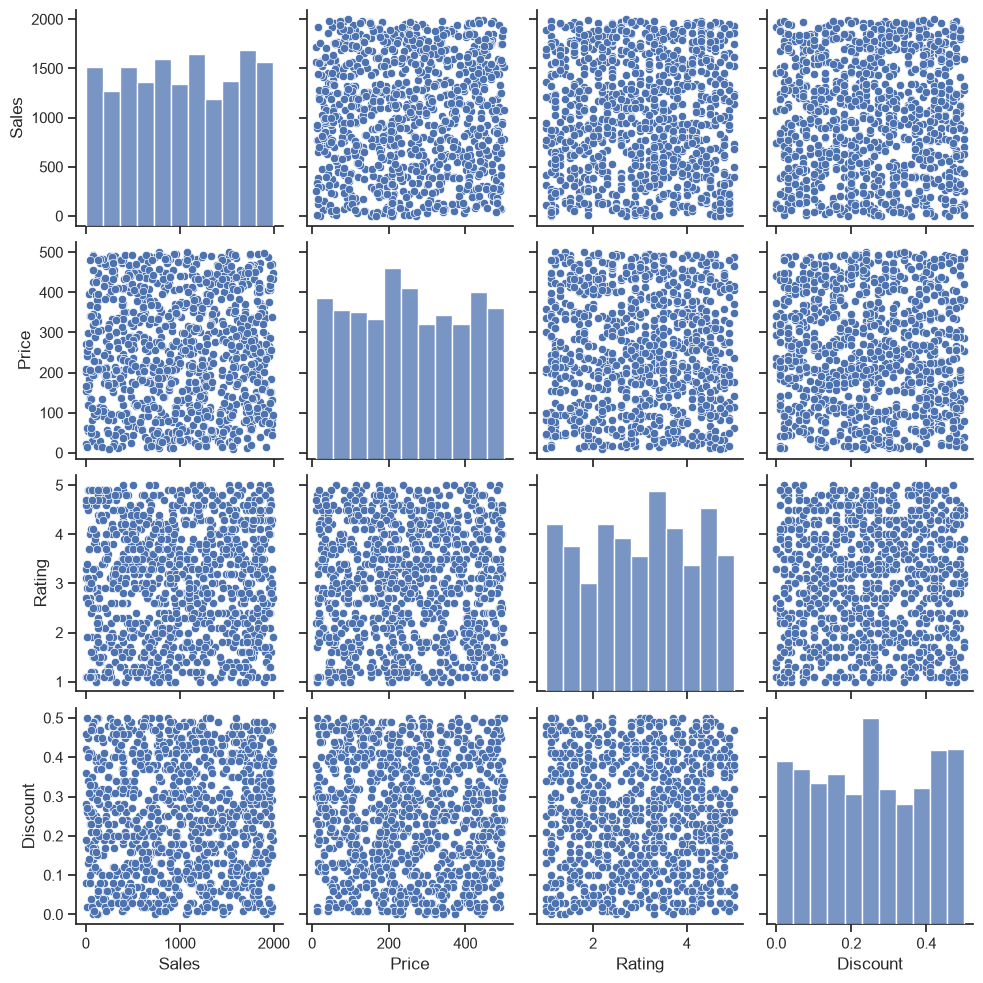

In [57]:
sns.set_theme(style="ticks")

sns.pairplot(df[["Sales", "Price", "Rating", "Discount"]])

Almost no correlation between any data points

In [19]:
transformed_df = df

transformed_df.to_csv('../data/transformed_df.csv', index=False)